In [ ]:
# Practice 9 - Algoritma Klasifikasi (Bagian 1)

## 🎓 Student Information

• **Name:** Ranu Ratmaja  
• **NIM:** 230401010104  
• **University:** UNSIA - Universitas Siber Asia  
• **Prodi:** PJJ - S1 Informatika  
• **Class:** IF401 Data Science

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimport')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Library berhasil diimport
   NumPy  : 2.0.2
   Pandas : 2.2.2


In [ ]:
# Load Dataset Breast Cancer Wisconsin
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0=malignant (ganas), 1=benign (jinak)

print(f'Shape dataset: {X.shape}')
print(f'\nDistribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))
print(f'\n0 = Malignant (ganas), 1 = Benign (jinak)')

Shape dataset: (569, 30)

Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64

0 = Malignant (ganas), 1 = Benign (jinak)


In [ ]:
# Train-Test Split & StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train set: {X_train.shape}, Test set: {X_test.shape}')

Train set: (455, 30), Test set: (114, 30)


In [ ]:
# Latih Logistic Regression
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)

# Prediksi
y_pred_log = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

print('✅ Logistic Regression berhasil dilatih')
print(f'\nKoefisien fitur (Top 5):')
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': log_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Koefisien'].abs().sort_values(ascending=False).index)
print(coef_df.head(5))

✅ Logistic Regression berhasil dilatih

Koefisien fitur (Top 5):
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


In [ ]:
# Latih Decision Tree
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5, random_state=42)
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

print('✅ Decision Tree berhasil dilatih')
print(f'\nFeature Importance (Top 5):')
importance_df = pd.DataFrame({'Fitur': X.columns, 'Importance': tree_model.feature_importances_})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df.head(5))

✅ Decision Tree berhasil dilatih

Feature Importance (Top 5):
                   Fitur  Importance
20          worst radius    0.751145
27  worst concave points    0.124955
11         texture error    0.046883
21         worst texture    0.033095
26       worst concavity    0.017573


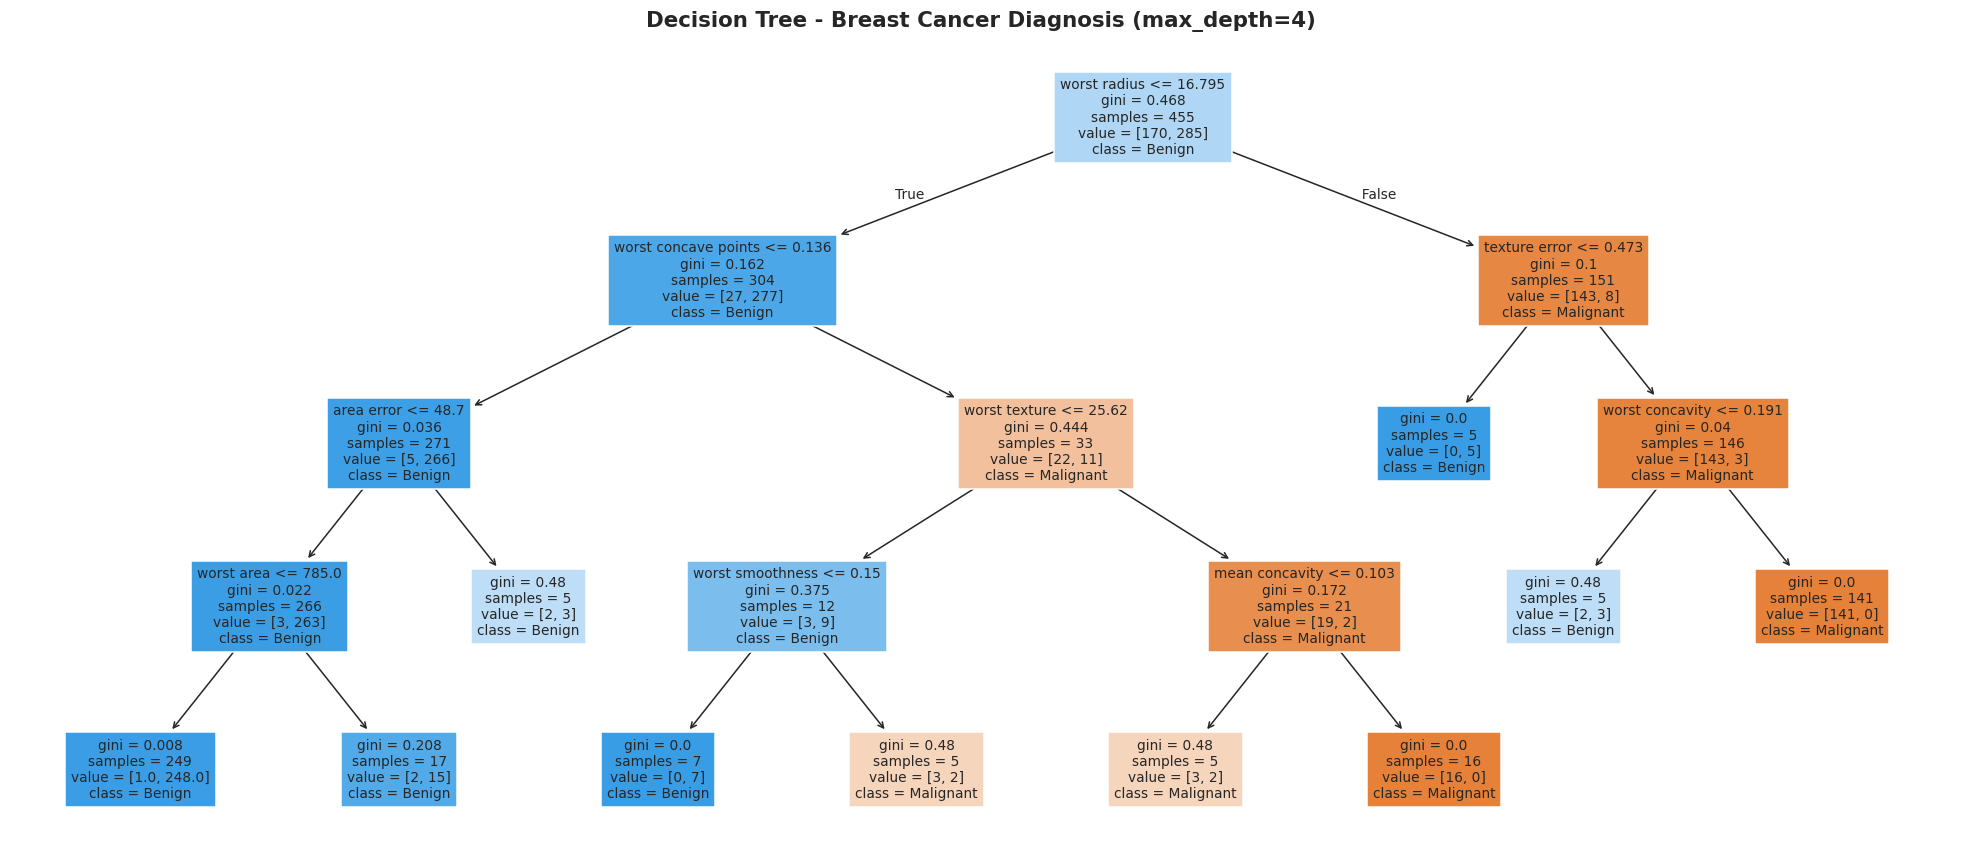

In [ ]:
# Visualisasi Decision Tree
plt.figure(figsize=(18, 8))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Malignant', 'Benign'],
          filled=True,
          fontsize=9)
plt.title('Decision Tree - Breast Cancer Diagnosis (max_depth=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix & Metrik Evaluasi
print('='*60)
print('EVALUASI MODEL - LOGISTIC REGRESSION VS DECISION TREE')
print('='*60)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f'\n{name}:')
    print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
    print(f'  Precision : {precision_score(y_test, y_pred):.3f}')
    print(f'  Recall    : {recall_score(y_test, y_pred):.3f}')
    print(f'  F1-Score  : {f1_score(y_test, y_pred):.3f}')
    print(f'\nConfusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["Malignant", "Benign"])}')

EVALUASI MODEL - LOGISTIC REGRESSION VS DECISION TREE

Logistic Regression:
  Accuracy  : 0.982
  Precision : 0.986
  Recall    : 0.986
  F1-Score  : 0.986

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Decision Tree:
  Accuracy  : 0.921
  Precision : 0.944
  Recall    : 0.931
  F1-Score  : 0.937

Confusion Matrix:
[[38  4]
 [ 5 67]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.88      0.90      0.89        42
      Benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92  

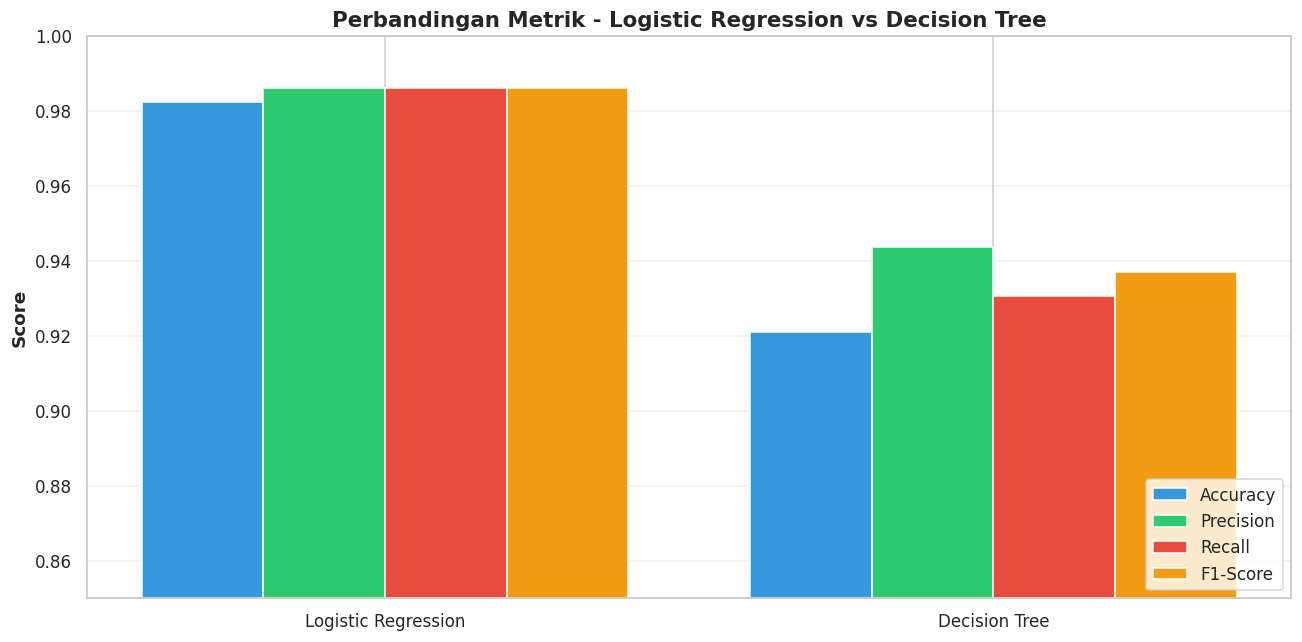


⚡ Kesimpulan:
   Logistic Regression unggul dengan Recall 0.986
   Decision Tree memiliki Recall 0.931


In [ ]:
# Visualisasi Perbandingan Metrik
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_tree)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_tree)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_tree)],
    'F1-Score': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_tree)]
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df['Model']))
width = 0.2

ax.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision', color='#2ecc71')
ax.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall', color='#e74c3c')
ax.bar(x + 1.5*width, metrics_df['F1-Score'], width, label='F1-Score', color='#f39c12')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Perbandingan Metrik - Logistic Regression vs Decision Tree', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Model'])
ax.legend(loc='lower right')
ax.set_ylim([0.85, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n⚡ Kesimpulan:')
print(f'   Logistic Regression unggul dengan Recall {recall_score(y_test, y_pred_log):.3f}')
print(f'   Decision Tree memiliki Recall {recall_score(y_test, y_pred_tree):.3f}')

## 💡 Analisis: Mengapa Recall Penting untuk Diagnosis Kanker?

Pada kasus diagnosis medis, khususnya kanker payudara, **Recall** (Sensitivity) adalah metrik paling kritis karena:

### 1️⃣ **False Negative Sangat Berbahaya**
• False Negative = Pasien **sebenarnya sakit kanker**, tapi model **prediksi sehat**  
• Konsekuensi: Pasien tidak mendapat pengobatan → kanker berkembang → fatal  
• Lebih baik **over-diagnose** (banyak false positive) daripada **melewatkan kasus nyata** (false negative)

### 2️⃣ **False Positive Masih Bisa Ditoleransi**
• False Positive = Pasien **sebenarnya sehat**, tapi model **prediksi sakit**  
• Konsekuensi: Pemeriksaan lanjutan (biopsi, tes ulang)  
• Meskipun merepotkan dan biaya tambahan, ini **tidak fatal** seperti False Negative

### 3️⃣ **Hasil Praktikum**
• **Logistic Regression:** Recall = **0.986** → Hanya **1 dari 72 kasus kanker terlewat**  
• **Decision Tree:** Recall = **0.931** → **5 dari 72 kasus kanker terlewat**  
• Untuk diagnosis medis, **Logistic Regression lebih aman** karena recall lebih tinggi

### ✅ **Kesimpulan**
Dalam konteks diagnosis kanker, **Recall > Precision**. Model dengan Recall tinggi memastikan sebagian besar kasus kanker terdeteksi, meskipun ada beberapa false alarm. Inilah mengapa dalam modul ini kita menekankan pentingnya Recall untuk kasus medis.

## 📖 Referensi

1. Scikit-learn Documentation - Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
2. Scikit-learn Documentation - Decision Trees: https://scikit-learn.org/stable/modules/tree.html
3. Breast Cancer Wisconsin Dataset: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)
4. Modul Pembelajaran Pertemuan 9 - Algoritma Klasifikasi Bagian 1, UNSIA 2026
5. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly Media